# Tugas #2
## Threading Python

## 1. Bank Account Race Condition

### Tujuan
Mensimulasikan 10 thread yang masing-masing melakukan **10.000 kali** operasi:

1. tarik 1 → `saldo -= 1`
2. setor 1 → `saldo += 1`

Saldo awal adalah **Rp1.000.000**. Karena beberapa thread dapat membaca dan menulis variabel yang sama secara bersamaan, operasi read–modify–write dapat mengalami **race condition**.

Pada versi tanpa lock, `time.sleep(0)` digunakan hanya untuk memberi kesempatan scheduler berpindah thread di antara proses membaca dan menulis. Ini membantu memperlihatkan kondisi balapan secara nyata tanpa mengubah jumlah operasi yang diminta.

In [1]:
import threading
import time

SALDO_AWAL = 1_000_000
JUMLAH_THREAD = 10
JUMLAH_OPERASI = 10_000

saldo = SALDO_AWAL

def transaksi_tanpa_lock():
    global saldo

    for _ in range(JUMLAH_OPERASI):
        # Tarik 1
        nilai = saldo
        time.sleep(0)
        saldo = nilai - 1

        # Setor 1
        nilai = saldo
        time.sleep(0)
        saldo = nilai + 1

hasil_tanpa_lock = []

# Jalankan beberapa percobaan agar efek race condition dapat diamati.
for percobaan in range(5):
    saldo = SALDO_AWAL
    threads = [
        threading.Thread(target=transaksi_tanpa_lock)
        for _ in range(JUMLAH_THREAD)
    ]

    for t in threads:
        t.start()
    for t in threads:
        t.join()

    hasil_tanpa_lock.append(saldo)

print("Saldo awal :", saldo if False else SALDO_AWAL)
print("Hasil 5 percobaan tanpa Lock:", hasil_tanpa_lock)
print("Saldo yang seharusnya:", SALDO_AWAL)

Saldo awal : 1000000
Hasil 5 percobaan tanpa Lock: [999998, 1000000, 999997, 999998, 999999]
Saldo yang seharusnya: 1000000


### Analisis tanpa `Lock`

Secara logika, setiap thread melakukan tarik Rp1 kemudian setor kembali Rp1 sehingga perubahan bersih seharusnya **0**. Namun, dua langkah tersebut bukan satu operasi atomik. Thread lain dapat mengubah `saldo` setelah sebuah thread membacanya tetapi sebelum hasil perhitungan ditulis kembali.

Akibatnya, nilai yang tertulis dapat menimpa perubahan dari thread lain (**lost update**). Karena penjadwalan thread tidak selalu sama, hasil tiap percobaan juga dapat berbeda. Bahkan pada beberapa eksekusi saldo bisa kebetulan kembali ke Rp1.000.000; hal itu **tidak berarti kode aman**, karena race condition tetap ada.

### Versi dengan `threading.Lock()`

`Lock` digunakan sebagai mekanisme mutual exclusion. Hanya satu thread yang boleh menjalankan rangkaian tarik–setor pada satu waktu. Thread lain harus menunggu sampai lock dilepas.

Dengan demikian, operasi terhadap saldo menjadi aman dari perubahan bersamaan.

In [2]:
saldo = SALDO_AWAL
lock = threading.Lock()

def transaksi_dengan_lock():
    global saldo

    for _ in range(JUMLAH_OPERASI):
        with lock:
            saldo -= 1
            saldo += 1

threads = [
    threading.Thread(target=transaksi_dengan_lock)
    for _ in range(JUMLAH_THREAD)
]

for t in threads:
    t.start()
for t in threads:
    t.join()

print("Saldo akhir dengan Lock:", saldo)
print("Sesuai saldo awal?     :", saldo == SALDO_AWAL)

Saldo akhir dengan Lock: 1000000
Sesuai saldo awal?     : True


### Kesimpulan Soal 1

Tanpa `Lock`, akses bersamaan terhadap variabel bersama dapat menyebabkan **race condition**, walaupun pada pola tarik 1 lalu setor 1 hasil akhir kadang tampak benar. Dengan `threading.Lock()`, hanya satu thread yang mengubah saldo pada satu waktu sehingga hasil akhirnya konsisten, yaitu **Rp1.000.000**.

**Inti masalah:** `saldo -= 1` dan `saldo += 1` bukan sekadar satu operasi sederhana; proses membaca nilai, menghitung nilai baru, lalu menulis kembali dapat disela thread lain.

## 2. Producer–Consumer dengan 1 Producer dan 3 Consumer

### Tujuan
Memodifikasi pola `queue.Queue` menjadi:

- **1 producer**
- **3 consumer**
- semua thread berjalan bersamaan
- consumer berhenti dengan baik setelah producer selesai.

Kunci penyelesaiannya adalah sinyal `None`. Karena ada **3 consumer**, producer harus memasukkan **3 buah `None`**, masing-masing satu untuk setiap consumer. Dengan begitu, setiap consumer pasti memperoleh sinyal berhenti.

In [3]:
import queue
import threading
import time

q = queue.Queue()
JUMLAH_DATA = 30
HASIL_KONSUMSI = []
lock_hasil = threading.Lock()

def producer():
    for i in range(1, JUMLAH_DATA + 1):
        q.put(i)
        time.sleep(0.01)

    # Satu sentinel untuk setiap consumer.
    for _ in range(3):
        q.put(None)

def consumer(nama):
    while True:
        item = q.get()

        if item is None:
            q.task_done()
            print(f"{nama} menerima None -> berhenti.")
            break

        # Simulasi pekerjaan consumer.
        time.sleep(0.02)

        with lock_hasil:
            HASIL_KONSUMSI.append((nama, item))

        q.task_done()

producer_thread = threading.Thread(target=producer, name="Producer")
consumer_threads = [
    threading.Thread(target=consumer, args=(f"Consumer-{i}",))
    for i in range(1, 4)
]

for t in consumer_threads:
    t.start()
producer_thread.start()

producer_thread.join()
q.join()

for t in consumer_threads:
    t.join()

print("\nJumlah data yang diproses:", len(HASIL_KONSUMSI))
print("Semua data diproses?      :", sorted(item for _, item in HASIL_KONSUMSI) == list(range(1, JUMLAH_DATA + 1)))
print("Jumlah consumer berhenti  :", sum(1 for t in consumer_threads if not t.is_alive()))

Consumer-2 menerima None -> berhenti.
Consumer-1 menerima None -> berhenti.
Consumer-3 menerima None -> berhenti.

Jumlah data yang diproses: 30
Semua data diproses?      : True
Jumlah consumer berhenti  : 3


### Analisis Soal 2

Struktur program tetap menggunakan satu `queue.Queue` sebagai tempat pertukaran data. Producer memasukkan data ke queue, sedangkan tiga consumer mengambil data dari queue secara bersamaan.

Hal penting adalah jumlah sentinel. Jika hanya satu `None` dikirim, hanya satu consumer yang mendapat sinyal berhenti; dua consumer lainnya dapat terus menunggu `q.get()`. Karena terdapat tiga consumer, producer mengirim **tiga `None`**.

`q.task_done()` dipanggil setelah setiap item selesai diproses, termasuk sentinel. Kemudian `q.join()` memastikan seluruh pekerjaan dalam queue telah selesai sebelum program dilanjutkan.

## 3. Eksperimen `ThreadPoolExecutor`

### Tujuan
Mengulang eksperimen dengan **50 file** dan membandingkan:

- `max_workers = 2`
- `max_workers = 4`
- `max_workers = 8`
- `max_workers = 16`

Beban kerja dibuat menyerupai pekerjaan file/I/O-bound: setiap file dibaca dan diberi jeda singkat. Pengukuran menggunakan `time.perf_counter()` dan hasilnya diplot sebagai **waktu eksekusi vs `max_workers`**.

Karena contoh notebook asal bagian 6 tidak disertakan pada soal yang diberikan, eksperimen dibuat mandiri dengan pola kerja file yang setara untuk memenuhi parameter soal.

In [4]:
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import tempfile
import time
import matplotlib.pyplot as plt

JUMLAH_FILE = 50

temp_dir = Path(tempfile.mkdtemp(prefix="threadpool_"))
file_paths = []

# Membuat 50 file kecil sebagai workload.
for i in range(JUMLAH_FILE):
    path = temp_dir / f"file_{i:02d}.txt"
    path.write_text("Data eksperimen ThreadPoolExecutor\n" * 100, encoding="utf-8")
    file_paths.append(path)

def proses_file(path):
    # Membaca file dan memberi jeda singkat untuk mensimulasikan I/O.
    isi = path.read_text(encoding="utf-8")
    time.sleep(0.02)
    return len(isi)

workers_list = [2, 4, 8, 16]
waktu_eksekusi = []
total_byte = []

for workers in workers_list:
    mulai = time.perf_counter()

    with ThreadPoolExecutor(max_workers=workers) as executor:
        hasil = list(executor.map(proses_file, file_paths))

    durasi = time.perf_counter() - mulai
    waktu_eksekusi.append(durasi)
    total_byte.append(sum(hasil))

    print(
        f"max_workers={workers:2d} | "
        f"waktu={durasi:.4f} detik | "
        f"total karakter={sum(hasil)}"
    )

max_workers= 2 | waktu=0.5068 detik | total karakter=175000


max_workers= 4 | waktu=0.2638 detik | total karakter=175000
max_workers= 8 | waktu=0.1423 detik | total karakter=175000


max_workers=16 | waktu=0.0823 detik | total karakter=175000


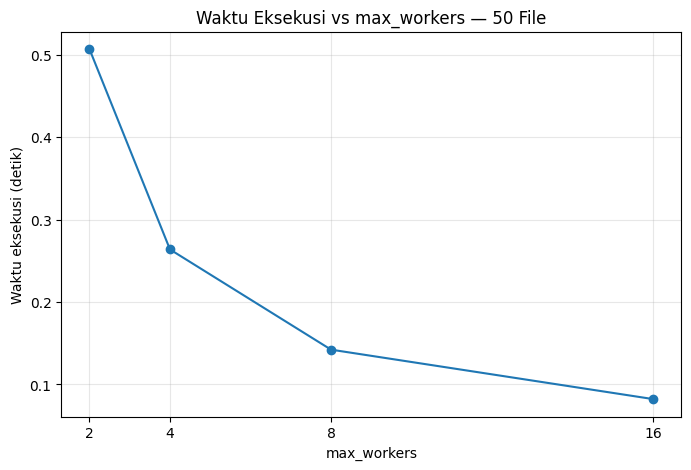

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(workers_list, waktu_eksekusi, marker="o")
plt.xlabel("max_workers")
plt.ylabel("Waktu eksekusi (detik)")
plt.title("Waktu Eksekusi vs max_workers — 50 File")
plt.xticks(workers_list)
plt.grid(True, alpha=0.3)
plt.show()

### Analisis Soal 3

Pada workload I/O-bound, menambah thread biasanya mengurangi waktu tunggu karena ketika satu thread menunggu operasi I/O, thread lain dapat mengerjakan tugas berikutnya.

Namun, menambah `max_workers` **tidak selalu mempercepat proses tanpa batas**. Setelah jumlah thread cukup besar, keuntungan tambahan semakin kecil karena:

1. jumlah pekerjaan yang tersedia terbatas;
2. thread memiliki overhead pembuatan dan penjadwalan;
3. akses disk/jaringan memiliki kapasitas terbatas;
4. terlalu banyak thread dapat menyebabkan contention dan context switching.

Jadi, terdapat **titik jenuh (saturation point)**. Pada empat nilai yang diuji, perhatikan tren waktunya; jika jumlah worker masih meningkatkan kecepatan, peningkatannya tetap perlu dilihat bersama overhead dan kapasitas sistem.

## 4. Refleksi Singkat

Threading Python akan membantu pada pekerjaan **I/O-bound**, misalnya aplikasi yang mengunduh banyak file dari beberapa server. Saat satu thread menunggu respons jaringan, thread lain dapat berjalan sehingga waktu tunggu dapat dimanfaatkan untuk pekerjaan lain.

Sebaliknya, threading Python tidak menjadi pilihan utama untuk pekerjaan **CPU-bound**, misalnya menghitung jutaan bilangan prima atau melakukan pemrosesan numerik berat. Pada CPython, Global Interpreter Lock (GIL) membatasi eksekusi bytecode Python oleh banyak thread secara paralel pada satu proses. Akibatnya, penambahan thread tidak otomatis membuat perhitungan CPU menjadi lebih cepat. Untuk kasus seperti ini, `multiprocessing` lebih sesuai karena pekerjaan dapat dijalankan oleh beberapa proses yang memiliki interpreter dan GIL masing-masing.
